#**Workforce displacement due to the rise of AI:**

##Introduction

## This notebook will not only explore the dataset containing the workforce displaced due to AI but will also have an interactive risk calculator where users can select their income range and predict their layoffs.

## Extracting the dataset

In [2]:
import pandas as pd
import streamlit as st

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Coding Projects/Datasets/ai_workforce_displacement_global_2020_2026.csv")

## Cleaning the dataset

### Checking for missing values, duplicates and dropping columns having inconsistencies.

In [4]:
print(f"Missing values:\n{df.isnull().sum()}")

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# View unique values in categorical columns to spot naming inconsistencies
print(f"Sectors: {df['industry_sector'].unique()}")

Missing values:
record_id                                 0
country                                   0
iso3_code                                 0
region                                    0
income_group                              0
year                                      0
quarter                                   0
quarter_label                             0
industry_sector                           0
sector_automation_risk_score              0
gdp_per_capita_usd                        0
ai_adoption_index                         0
pct_sector_workforce_displaced            0
pct_sector_workforce_new_roles_created    0
net_workforce_change_pct                  0
ai_cited_layoff_announcements             0
ai_skill_wage_premium_pct                 0
pct_workforce_female                      0
pct_displaced_roles_female                0
reskilling_programs_count                 0
govt_ai_policy_score_1_to_10              0
ai_tool_adoption_pct                      0
data_source_note

In [5]:
# Dropping 'record_id' as it is a serial index and 'data_source_notes' as it contains descriptive text
cols_to_drop = ['record_id', 'data_source_notes']
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Columns remaining: {len(df_cleaned.columns)}")
df_cleaned.head(2)

Columns remaining: 21


,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,gdp_per_capita_usd,...,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct
0,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.382,63514,...,0.0406,0.0348,-0.0058,32,0.311,0.28,0.275,52,6.4,0.280
1,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.608,63514,...,0.0517,0.0423,-0.0094,51,0.304,0.48,0.511,39,6.5,0.559


In [6]:
# Finalize the cleaned dataframe
df_cleaned = df.drop(columns=['record_id', 'data_source_notes'])

# Save to a new CSV for the Streamlit app to use
df_cleaned.to_csv("cleaned_workforce_data.csv", index=False)

drive_path = "/content/drive/MyDrive/Coding Projects/Datasets/cleaned_workforce_data.csv"

# Save the cleaned dataframe to your permanent Drive storage
df_cleaned.to_csv(drive_path, index=False)

print(f"File successfully saved to: {drive_path}")

File successfully saved to: /content/drive/MyDrive/Coding Projects/Datasets/cleaned_workforce_data.csv


##Feature Engineering & Selection for the Risk Calculator

To build a functional and intuitive risk assessment tool, I have narrowed the dataset down to 21 relevant columns. The calculator's logic is powered by three distinct categories of data that help quantify the intersection of AI and the global workforce

Predictors:

industry_sector: Categorizes the user's professional field (e.g., Technology, Finance, Healthcare), which carries inherent baseline automation risks.

income_group: Distinguishes between High, Upper Middle, and Lower Middle-income nations, accounting for differences in infrastructure and AI deployment speed.

govt_ai_policy_score_1_to_10: Acts as a modifier to show how national regulation and support can either accelerate or shield a sector from sudden displacement.

Targets:

sector_automation_risk_score: A probability metric indicating the percentage of tasks within a sector that are technically feasible to automate using currently available AI tools.

pct_sector_workforce_displaced: The projected percentage of the total workforce in that specific industry likely to face role redundancy by 2026.

Economic impact (upskilling incentive)

ai_skill_wage_premium_pct: Beyond displacement, this feature calculates the potential salary increase for workers who successfully transition into AI-augmented roles.

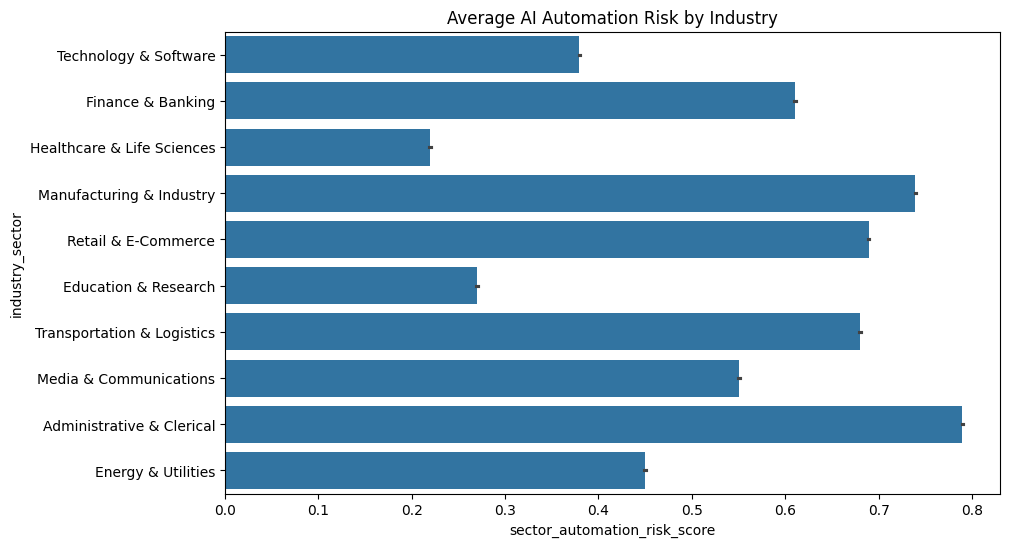

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Show top 5 sectors by Automation Risk to prove the data's narrative
plt.figure(figsize=(10, 6))
sns.barplot(data=df_cleaned, x='sector_automation_risk_score', y='industry_sector', estimator='mean')
plt.title('Average AI Automation Risk by Industry')
plt.show()

##Interface for the calculator

In [8]:
%%writefile workforce_displacement.py
import pandas as pd
import streamlit as st

try:
    df = pd.read_csv("/content/drive/MyDrive/Coding Projects/Datasets/cleaned_workforce_data.csv")
except FileNotFoundError:
    df = pd.read_csv("cleaned_workforce_data.csv")

st.title("🌐 AI Workforce Risk Calculator")
st.markdown("---")

# User Inputs based on dataset columns
sector = st.selectbox("Select your Industry:", sorted(df['industry_sector'].unique()))
income = st.selectbox("Select Country Income Group:", sorted(df['income_group'].unique()))

# Filter data for 2026 projections
filtered_data = df[(df['industry_sector'] == sector) &
                    (df['income_group'] == income) &
                    (df['year'] == 2026)]

if not filtered_data.empty:
    # Calculating metrics from the filtered dataset
    avg_risk = filtered_data['sector_automation_risk_score'].mean()
    wage_premium = filtered_data['ai_skill_wage_premium_pct'].mean()
    displaced = filtered_data['pct_sector_workforce_displaced'].mean()

    # Displaying Metrics in three columns for a professional dashboard look
    col1, col2, col3 = st.columns(3)
    col1.metric("Automation Risk", f"{avg_risk:.2f}")
    col2.metric("Displacement %", f"{displaced*100:.1f}%")
    col3.metric("Wage Premium", f"+{wage_premium*100:.1f}%")

    st.success(f"**Insight:** In the {sector} sector for {income} regions, workers who gain AI proficiency see an average **{wage_premium*100:.1f}% wage premium**.")
else:
    st.warning("No data found for this specific selection. Please try another combination.")

Overwriting workforce_displacement.py


## Retrieving the session IP as a tunnel password and launches the Streamlit app via a public Localtunnel bridge.

In [9]:
# Getting the IP address for the Localtunnel password
!curl ipv4.icanhazip.com

# Launching the app using the python module path to avoid "command not found" errors
!python -m streamlit run workforce_displacement.py --server.enableCORS false --server.enableXsrfProtection false & npx localtunnel --port 8501

34.138.8.62
⠙⠹⠸⠼⠴⠦⠧⠇

⠏⠋⠙⠹⠸⠼⠴your url is: https://twelve-regions-take.loca.lt
2026-05-13 13:41:05.736 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.138.8.62:8501

  Stopping...
^C
